# Домашнее задание: Низкоранговое приближение матрицы с помощью SVD-разложения

## Введение

В этом задании вы реализуете построение низкорангового приближения матрицы с использованием сингулярного разложения (SVD).

## 1. Теория: SVD-разложение

**Сингулярное разложение (SVD)** — это факторизация матрицы $A \in \mathbb{R}^{m \times n}$ в виде:

$$A = U \Sigma V^T$$

где:
- $U \in \mathbb{R}^{m \times m}$ — ортогональная матрица левых сингулярных векторов
- $\Sigma \in \mathbb{R}^{m \times n}$ — диагональная матрица сингулярных чисел $\sigma_1 \geq \sigma_2 \geq \ldots \geq \sigma_r \geq 0$
- $V \in \mathbb{R}^{n \times n}$ — ортогональная матрица правых сингулярных векторов

Сингулярные числа $\sigma_i$ упорядочены по убыванию и характеризуют "важность" соответствующих компонент разложения.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Создаём случайную матрицу 20x20
np.random.seed(42)
A = np.random.randn(20, 20)

print(f"Размер матрицы A: {A.shape}")
print(f"Ранг матрицы A: {np.linalg.matrix_rank(A)}")

Размер матрицы A: (20, 20)
Ранг матрицы A: 20


## Задание 1: Вычисление SVD-разложения

Вычислите SVD-разложение матрицы A.

In [2]:
# TODO: Вычислите SVD-разложение матрицы A
# Используйте np.linalg.svd с параметром full_matrices=True
U, sigma, Vt = np.linalg.svd(A, full_matrices=True)

print(f"Размер U: {U.shape}")
print(f"Размер sigma: {sigma.shape}")
print(f"Размер V^T: {Vt.shape}")
print(f"\nСингулярные числа:\n{sigma}")

Размер U: (20, 20)
Размер sigma: (20,)
Размер V^T: (20, 20)

Сингулярные числа:
[7.39164965 7.1878167  6.70171127 6.25021026 6.00001848 5.52386693
 4.84739334 4.47884259 3.89044483 3.73073014 3.35601317 2.73459262
 2.63110298 2.17184646 1.95233183 1.628475   0.92898647 0.74516702
 0.68491429 0.1415186 ]


## 2. Теория: Низкоранговое приближение

**Теорема Эккарта-Янга:** Наилучшее приближение матрицы $A$ матрицей ранга $k$ в норме Фробениуса даётся усечённым SVD:

$$A_k = U_k \Sigma_k V_k^T = \sum_{i=1}^{k} \sigma_i u_i v_i^T$$

где $U_k$, $\Sigma_k$, $V_k$ — первые $k$ столбцов/строк соответствующих матриц.

**Ошибка приближения:**

$$\|A - A_k\|_F = \sqrt{\sum_{i=k+1}^{r} \sigma_i^2}$$

Чем больше $k$, тем точнее приближение.

## Задание 2: Реализация функции низкорангового приближения

Реализуйте функцию, которая строит низкоранговое приближение матрицы заданного ранга k.

In [5]:
def low_rank_approximation(U, sigma, Vt, k):
    """
    Строит низкоранговое приближение матрицы ранга k.

    Параметры:
        U: левые сингулярные векторы
        sigma: сингулярные числа (одномерный массив)
        Vt: транспонированные правые сингулярные векторы
        k: желаемый ранг приближения

    Возвращает:
        A_k: матрица ранга k
    """
    # TODO: Возьмите первые k столбцов матрицы U
    U_k = U[:, :k]

    # TODO: Возьмите первые k сингулярных чисел
    sigma_k = sigma[:k]

    # TODO: Возьмите первые k строк матрицы Vt
    Vt_k = Vt[:k]

    # TODO: Восстановите приближение: A_k = U_k @ diag(sigma_k) @ Vt_k
    # Используйте np.diag(sigma_k) для создания диагональной матрицы
    A_k = U_k @ np.diag(sigma_k) @ Vt_k

    return A_k

In [6]:
# Пример: приближение ранга 5
A_5 = low_rank_approximation(U, sigma, Vt, k=5)
print(f"Ранг приближения A_5: {np.linalg.matrix_rank(A_5)}")
print(f"Ошибка ||A - A_5||_F = {np.linalg.norm(A - A_5, 'fro'):.6f}")

Ранг приближения A_5: 5
Ошибка ||A - A_5||_F = 11.911157


## 3. Зависимость ошибки от ранга приближения

Построим график зависимости ошибки приближения $\|A - A_k\|_F$ от ранга $k$.

## Задание 3: Вычисление ошибки для всех рангов

Вычислите ошибку приближения для всех возможных рангов от 1 до 20.

In [ ]:
import matplotlib.pyplot as plt

In [21]:
# Вычисляем ошибку для всех возможных рангов
ranks = range(1, 21)
errors = []

for k in ranks:
    # TODO: Постройте приближение ранга k
    A_k = low_rank_approximation(U, sigma, Vt, k=k)

    # TODO: Вычислите ошибку в норме Фробениуса: ||A - A_k||_F
    # Используйте np.linalg.norm с параметром 'fro'
    error = np.linalg.norm(A - A_k, 'fro')

    errors.append(error)

## Задание 4: Теоретическая ошибка

Вычислите теоретическую ошибку по формуле $\sqrt{\sum_{i=k+1}^{r} \sigma_i^2}$.

In [22]:
# TODO: Вычислите теоретическую ошибку для каждого ранга k
# Формула: sqrt(sum(sigma[k:]^2))
theoretical_errors = []

for k in ranks:
    # TODO: Вычислите теоретическую ошибку для ранга k
    # Подсказка: нужно взять сингулярные числа начиная с индекса k и вычислить sqrt(sum(sigma[k:]**2))
    theoretical_error = np.sqrt(np.sum(sigma[k:]**2))
    theoretical_errors.append(theoretical_error)

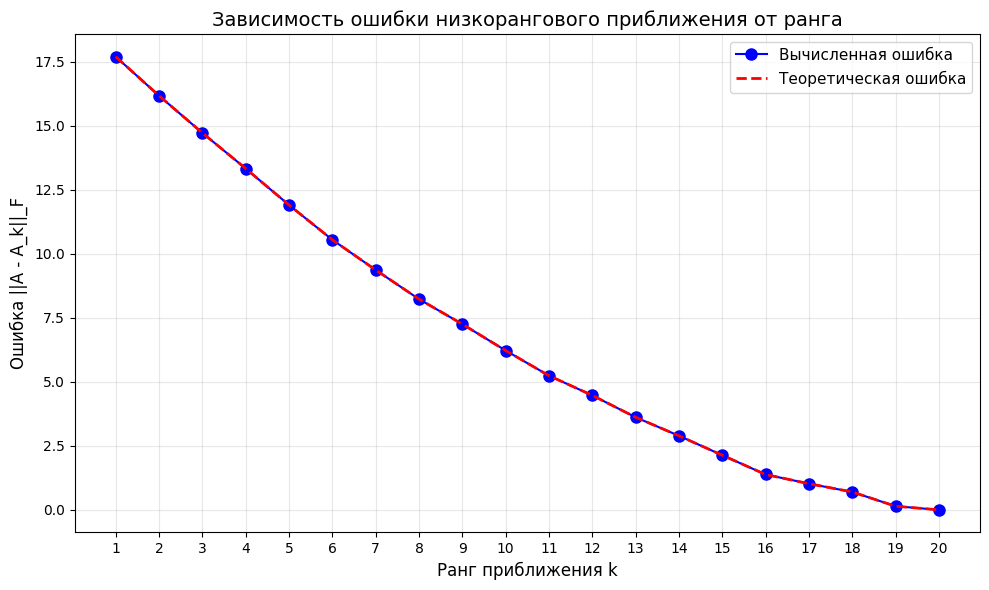

In [23]:
# Строим график
plt.figure(figsize=(10, 6))
plt.plot(ranks, errors, 'bo-', label='Вычисленная ошибка', markersize=8)
plt.plot(ranks, theoretical_errors, 'r--', label='Теоретическая ошибка', linewidth=2)
plt.xlabel('Ранг приближения k', fontsize=12)
plt.ylabel('Ошибка ||A - A_k||_F', fontsize=12)
plt.title('Зависимость ошибки низкорангового приближения от ранга', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.xticks(ranks)
plt.tight_layout()
plt.show()

## Задание 5: Проверка совпадения ошибок

Убедитесь, что вычисленная и теоретическая ошибки совпадают.

In [24]:
# TODO: Вычислите максимальное расхождение между вычисленной и теоретической ошибкой
max_difference = np.max(np.abs(np.array(errors) - np.array(theoretical_errors)))

print(f"Максимальное расхождение между вычисленной и теоретической ошибкой: {max_difference:.2e}")
print("\nСравнение ошибок для нескольких рангов:")
for k in [1, 5, 10, 15, 19]:
    print(f"  k={k}: вычисленная = {errors[k-1]:.6f}, теоретическая = {theoretical_errors[k-1]:.6f}")

Максимальное расхождение между вычисленной и теоретической ошибкой: 2.41e-14

Сравнение ошибок для нескольких рангов:
  k=1: вычисленная = 17.706458, теоретическая = 17.706458
  k=5: вычисленная = 11.911157, теоретическая = 11.911157
  k=10: вычисленная = 6.225062, теоретическая = 6.225062
  k=15: вычисленная = 2.135265, теоретическая = 2.135265
  k=19: вычисленная = 0.141519, теоретическая = 0.141519


## Задание 6 (дополнительное): Доля сохранённой энергии

Вычислите, какую долю "энергии" (суммы квадратов сингулярных чисел) сохраняет приближение ранга k.

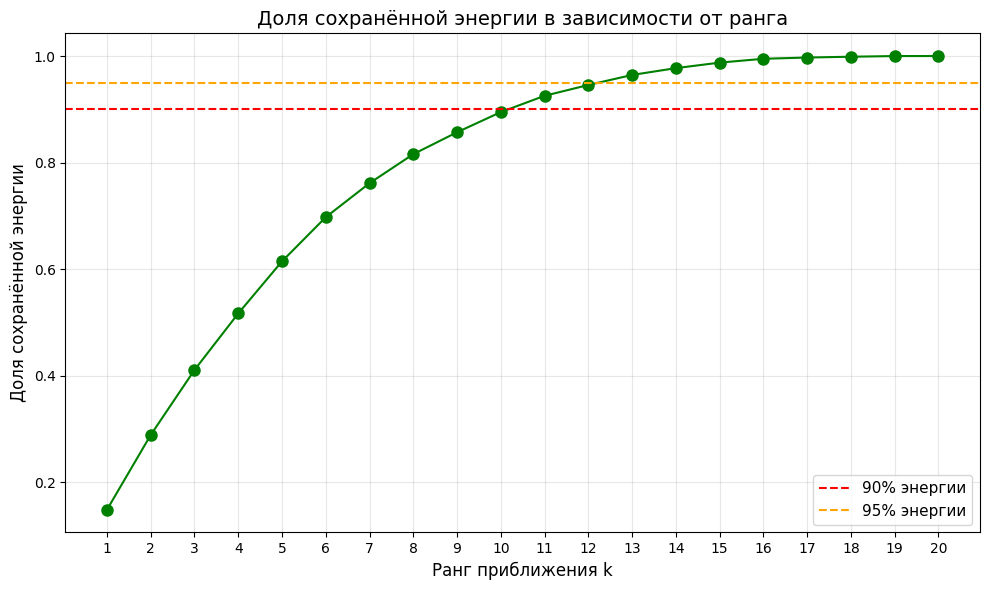


Минимальный ранг для 90% энергии: 11
Минимальный ранг для 95% энергии: 13


In [25]:
# TODO: Вычислите полную энергию (сумму квадратов всех сингулярных чисел)
total_energy = np.sum(sigma**2)

# TODO: Вычислите долю сохранённой энергии для каждого ранга k
# Формула: sum(sigma[:k]**2) / total_energy
energy_ratios = []
for k in ranks:
    energy_ratio = np.sum(sigma[:k]**2) / total_energy
    energy_ratios.append(energy_ratio)

# Построение графика
plt.figure(figsize=(10, 6))
plt.plot(ranks, energy_ratios, 'go-', markersize=8)
plt.axhline(y=0.9, color='r', linestyle='--', label='90% энергии')
plt.axhline(y=0.95, color='orange', linestyle='--', label='95% энергии')
plt.xlabel('Ранг приближения k', fontsize=12)
plt.ylabel('Доля сохранённой энергии', fontsize=12)
plt.title('Доля сохранённой энергии в зависимости от ранга', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.xticks(ranks)
plt.tight_layout()
plt.show()

# Найдём минимальный ранг для 90% и 95% энергии
k_90 = np.argmax(np.array(energy_ratios) >= 0.9) + 1
k_95 = np.argmax(np.array(energy_ratios) >= 0.95) + 1
print(f"\nМинимальный ранг для 90% энергии: {k_90}")
print(f"Минимальный ранг для 95% энергии: {k_95}")

## Выводы

1. SVD-разложение позволяет построить оптимальное низкоранговое приближение матрицы
2. Ошибка приближения монотонно убывает с ростом ранга
3. При $k = \text{rank}(A)$ ошибка равна нулю (точное восстановление)
4. Теоретическая формула ошибки точно совпадает с вычисленной